## Importar datos y generar geodataframe

In [ ]:
# --- Núcleo científico y geoespacial ---
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from itertools import combinations
from shapely.geometry import LineString


Debes trabajar en coordenadas proyectadas métricas (UTM) para que las distancias estén en metros.

Revisa que col_x, col_y y col_ph apunten a tus nombres reales.

Si tu finca está en otra zona UTM, ajusta el EPSG (por ejemplo 32716 para zona 18S).

In [ ]:
# --- 1. Cargar datos desde Excel ---
# Ajusta la ruta a tu archivo. En Colab suele ser /content/...
df = pd.read_excel("/content/Tabla_suelos.xlsx", sheet_name="Suelo")

# --- 2. Nombra aquí las columnas de coordenadas y del parámetro ---
# Si tus columnas reales se llaman 'ESTE' y 'NORTE', cámbialas aquí:
col_x  = "X"     # ej. "ESTE"
col_y  = "Y"     # ej. "NORTE"
col_ph = "Ph"    # tu variable de interés, p. ej. pH

# Verificación rápida (lanza error si falta algo)
for c in [col_x, col_y, col_ph]:
    assert c in df.columns, f"Falta la columna requerida: {c}"

# --- 3. Crear GeoDataFrame de puntos (elige el CRS correcto) ---
# EPSG:32716 = UTM Zona 16S; cámbialo a tu zona real si corresponde.
gdf_punto = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[col_x], df[col_y]),
    crs="EPSG:32716"
)

gdf_punto.head(), gdf_punto.crs


(   fid  ID  Arena  Arcilla  Limo                Textura    Ph    MO     N  \
 0    1   1     35       22    43                 Franco  4.20  2.46  0.12   
 1    2   2     47       20    33                 Franco  4.07  2.28  0.11   
 2    3   3     23       30    47  Franco Arcillo Limoso  4.17  2.81  0.14   
 3    4   4     17       31    52  Franco Arcillo Limoso  3.85  2.63  0.13   
 4    5   5     23       24    53          Franco Limoso  4.16  3.60  0.18   
 
    P_ppm  ...    Mg    AI     H  CICe  Bas_Camb  Ac_Camb  Sat_AI          X  \
 0   0.58  ...  0.41  2.49  1.31  7.44        49       51      33  405495.08   
 1   2.28  ...  0.23  3.07  1.53  6.97        34       66      44  405530.26   
 2   2.56  ...  0.23  2.56  0.64  5.27        39       61      49  405585.65   
 3   6.62  ...  0.22  3.02  2.68  7.77        27       73      39  405575.73   
 4   3.13  ...  0.40  2.56  0.94  6.74        48       52      38  405542.69   
 
            Y                     geometry  
 0 

Cada puntito es un par de muestras.

Eje X: distancia entre las dos muestras. Eje Y: γ = 0.5 (Δvalor)².

Si la variable (pH) muestra autocorrelación espacial, verás que para distancias cortas los puntos tienden a γ bajos y a medida que aumenta la distancia, γ crece hasta estabilizarse (el “sill”).

Nubes muy densas dificultan ver estructura; por eso luego binamos (agrupamos por rangos de distancia).

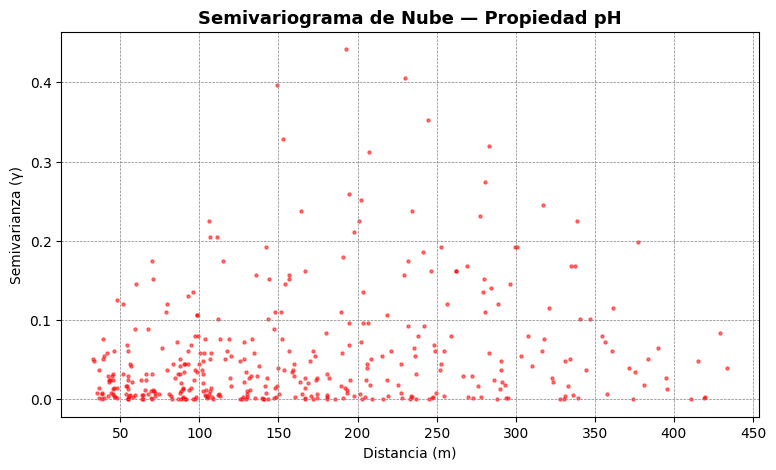

Index(['dx', 'dy', 'distancia', 'gamma', 'geometry'], dtype='object')

In [ ]:
# --- 4. Extraer arrays y tamaño ---
x = gdf_punto[col_x].to_numpy(float)
y = gdf_punto[col_y].to_numpy(float)
z = gdf_punto[col_ph].to_numpy(float)
n = len(z)

# --- 5. Calcular semivarianza entre todos los pares ---
pares = []
for (i1, p1), (i2, p2) in combinations(gdf_punto.iterrows(), 2):
    x1, y1, v1 = p1[col_x], p1[col_y], p1[col_ph]
    x2, y2, v2 = p2[col_x], p2[col_y], p2[col_ph]

    dist  = np.hypot(x2 - x1, y2 - y1)      # distancia euclidiana (m)
    gamma = 0.5 * (v2 - v1) ** 2            # semivarianza empírica

    pares.append({
        "dx": i1 + 1,                        # índice (opcional/ilustrativo)
        "dy": i2 + 1,
        "distancia": dist,
        "gamma": gamma,
        "geometry": LineString([(x1, y1), (x2, y2)])
    })

# Usa el MISMO CRS que gdf_punto (consistencia)
gdf_pares = gpd.GeoDataFrame(pares, crs=gdf_punto.crs)

# --- 6. Graficar la nube de pares ---
plt.figure(figsize=(9,5))
plt.scatter(gdf_pares["distancia"], gdf_pares["gamma"], s=5, alpha=0.5, c='red')
plt.xlabel('Distancia (m)')
plt.ylabel('Semivarianza (γ)')
plt.title('Semivariograma de Nube — Propiedad pH', fontweight='bold', fontsize=13)
plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.savefig('semivariograma_nube.jpg', dpi=300, format='jpg', bbox_inches='tight')
plt.show()

gdf_pares.columns


In [ ]:
# Exporta el shapefile de líneas entre pares (puede ser pesado para N grande)
gdf_pares.to_file("Distancia_pares.shp")

El Variogram Map mapea γ(h) en un plano de lags direccionales: eje X = ΔX, eje Y = ΔY.

Colores bajos (γ pequeño) indican mayor continuidad en esa dirección/longitud de desplazamiento; colores altos indican variación fuerte.

Si hay anisotropía, verás “óvalos”/patrones alargados: el eje largo apunta a la dirección de mayor continuidad (menor γ).

In [ ]:
# !pip install -U kaleido   # solo si usarás export de figuras con plotly (opcional)
import plotly.graph_objects as go
import plotly.express as px

# ---------------------- Construcción del Variogram Map ----------------------
def build_variogram_map(x, y, z, nbins=80, max_range_frac=0.6, pair_cap=1_000_000, random_state=42):
    """
    Calcula un mapa de variograma empírico γ(h) binned sobre el plano de lags (hx, hy).
    Aplica simetría (dx,dy) y (-dx,-dy) para estabilizar.
    - nbins: resolución de la grilla
    - max_range_frac: recorta a un % del tamaño máximo del muestreo (evitar ruido a largas distancias)
    - pair_cap: tope de pares para no explotar memoria/tiempo (muestra aleatoria si se supera)
    """
    x = np.asarray(x, float); y = np.asarray(y, float); z = np.asarray(z, float)
    n = len(z)
    total_pairs = n*(n-1)//2

    # 1) Elegir pares (muestra si hay demasiados)
    if total_pairs > pair_cap:
        rng = np.random.default_rng(random_state)
        K = min(3000, n)         # nº de puntos semilla
        M = min(50, n-1)         # nº de vecinos por semilla
        idx = rng.choice(n, size=K, replace=False)
        pairs = []
        for i in idx:
            others = rng.choice([j for j in range(n) if j != i], size=M, replace=False)
            for j in others:
                a, b = (i, j) if i < j else (j, i)
                pairs.append((a, b))
        pairs = np.unique(np.asarray(pairs, dtype=int), axis=0)
    else:
        pairs = np.array(list(combinations(range(n), 2)), dtype=int)

    # 2) Lags y semivarianza
    dx = x[pairs[:,1]] - x[pairs[:,0]]
    dy = y[pairs[:,1]] - y[pairs[:,0]]
    gamma = 0.5 * (z[pairs[:,1]] - z[pairs[:,0]])**2

    # 3) Recorte por rango máximo (evitar ruido extremo)
    width  = x.max() - x.min()
    height = y.max() - y.min()
    Hmax = max_range_frac * max(width, height)

    dist = np.hypot(dx, dy)
    m = dist <= Hmax
    dx = dx[m]; dy = dy[m]; gamma = gamma[m]

    # 4) Bins regulares en el plano (hx, hy)
    hx_edges = np.linspace(-Hmax, Hmax, nbins+1)
    hy_edges = np.linspace(-Hmax, Hmax, nbins+1)
    hx_centers = 0.5*(hx_edges[:-1] + hx_edges[1:])
    hy_centers = 0.5*(hy_edges[:-1] + hy_edges[1:])

    sums = np.zeros((nbins, nbins), float)
    counts = np.zeros((nbins, nbins), int)

    ix = np.searchsorted(hx_edges, dx, side='right') - 1
    iy = np.searchsorted(hy_edges, dy, side='right') - 1
    valid = (ix >= 0) & (ix < nbins) & (iy >= 0) & (iy < nbins)
    ix = ix[valid]; iy = iy[valid]; g = gamma[valid]

    # 5) Acumular γ y aplicar simetría (espejo) para estabilizar
    for cx, cy, val in zip(ix, iy, g):
        sums[cy, cx] += val; counts[cy, cx] += 1
        mx = nbins - 1 - cx
        my = nbins - 1 - cy
        sums[my, mx] += val; counts[my, mx] += 1

    with np.errstate(invalid='ignore', divide='ignore'):
        grid = sums / counts
    grid[~np.isfinite(grid)] = np.nan

    extent = (hx_edges[0], hx_edges[-1], hy_edges[0], hy_edges[-1])
    stats = {"n_pairs_used": int(valid.sum())*2, "Hmax": float(Hmax), "nbins": nbins}
    return grid, extent, hx_centers, hy_centers, stats


# --- Ejecutar el mapa de variograma ---
grid, extent, hx_c, hy_c, stats = build_variogram_map(x, y, z, nbins=30, max_range_frac=0.6)
stats


{'n_pairs_used': 606, 'Hmax': 255.13199999998324, 'nbins': 30}

🔹 n_pairs_used: 606

➡️ Número de pares de puntos efectivamente usados en el cálculo del mapa de variograma.

En total se formaron miles de pares posibles (N*(N–1)/2), pero para evitar que el cálculo sea muy pesado se usa un muestreo limitado (controlado por pair_cap).

Este valor indica que 606 pares válidos se consideraron finalmente.

Si fueran muy pocos (<200), el mapa podría verse “ruidoso” o con patrones poco claros.

Con 606 pares, ya hay una muestra aceptable para detectar anisotropía y patrones espaciales coherentes.

🔹 Hmax: 255.13

➡️ Es la distancia máxima (en metros, si tu CRS está en metros) que se incluyó en el análisis del mapa de variograma.

Se calcula como una fracción (max_range_frac) del tamaño máximo de tu zona de muestreo (por defecto 0.6).

En tu caso, solo se analizaron los pares con distancia ≤ 255 m, porque más allá la semivarianza suele volverse ruidosa y ya no aporta estructura espacial útil.

🔸 Interpretación práctica:

Los patrones de variabilidad (γ(h)) que observas en el mapa reflejan la estructura espacial hasta unos 255 m.

Más allá de ese rango no se consideraron, porque el modelo asume que ya no hay correlación significativa (o los pares son muy pocos).

🔹 nbins: 30

➡️ Es el número de divisiones (celdas o bins) por eje que se usaron en la grilla del mapa de variograma.

El mapa resultante tiene una matriz de 30 × 30 celdas, donde cada celda contiene la semivarianza media de todos los pares cuya separación (ΔX, ΔY) cae dentro de ese rango.

A más nbins, más detalle (pero también más ruido); a menos nbins, más suavizado.

🔸 Interpretación práctica:

Con nbins=30 logras un equilibrio razonable entre resolución y estabilidad estadística.

Cada celda del mapa representa un promedio de γ(h) para desplazamientos específicos en X e Y dentro del rango ±255 m.

✅ En resumen
Parámetro	Qué mide	Interpretación práctica
n_pairs_used	Pares de puntos analizados	Cantidad de información espacial utilizada (606 pares = bueno)
Hmax	Rango máximo (m)	Hasta qué distancia se analizó la dependencia espacial (~255 m)
nbins	Resolución de grilla	Nivel de detalle del mapa de anisotropía (30×30 celdas)

In [ ]:
def estimate_principal_direction(hx_centers, hy_centers, grid):
    """
    Estima dirección de mayor continuidad (menor γ) mediante un PCA ponderado.
    Pondera más celdas con γ más bajo: W = Gmax - G.
    Devuelve:
      - Angulo_x_grado: respecto al eje +X (0..180)
      - Azimuth_norte_grado: azimut desde el Norte (0..180)
      - Relacion_anisotropia_mayor_menor: razón de ejes (elongación)
    """
    HX, HY = np.meshgrid(hx_centers, hy_centers)
    G = np.array(grid, float)
    valid = np.isfinite(G)
    if not np.any(valid):
        return None

    Gmax = np.nanmax(G)
    W = (Gmax - G)
    W[~valid] = 0.0
    W[W < 0] = 0.0

    X = HX.ravel(); Y = HY.ravel(); w = W.ravel()
    wsum = w.sum()
    if wsum == 0:
        return None

    mx = (w*X).sum()/wsum; my = (w*Y).sum()/wsum
    Xc = X - mx; Yc = Y - my
    Sxx = (w*(Xc*Xc)).sum()/wsum
    Syy = (w*(Yc*Yc)).sum()/wsum
    Sxy = (w*(Xc*Yc)).sum()/wsum
    cov = np.array([[Sxx, Sxy],[Sxy, Syy]])
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]; vecs = vecs[:, order]
    v_major = vecs[:,0]

    angle_from_x = (math.degrees(math.atan2(v_major[1], v_major[0])) + 180.0) % 180.0
    az_north = (90.0 - angle_from_x) % 180.0
    ratio = math.sqrt(vals[0]/vals[1]) if vals[1] > 0 else np.inf
    return {
        "Angulo_x_grado": round(float(angle_from_x),3),
        "Azimuth_norte_grado": round(float(az_north),3),
        "Relacion_anisotropia_mayor_menor": round(float(ratio),3)
    }

direction = estimate_principal_direction(hx_c, hy_c, grid)
direction


{'Angulo_x_grado': 89.138,
 'Azimuth_norte_grado': 0.862,
 'Relacion_anisotropia_mayor_menor': 2.424}

1) Angulo_x_grado: 89.138

Es el ángulo del eje de mayor continuidad medido desde el eje +X (Este), en sentido antihorario.

≈ 89.1° es prácticamente 90°, o sea, el eje principal está casi alineado con Y → dirección Norte–Sur.

2) Azimuth_norte_grado: 0.862

Es el azimut del eje principal medido desde el Norte, en sentido horario (0–180°).

0.862° ≈ Norte–Sur (apenas desviado hacia el Este ~0.86°).

Traducción simple: tu variable (p. ej., pH) es más continua (menos variación γ) si te desplazas a lo largo de un eje casi N–S.

3) Relacion_anisotropia_mayor_menor: 2.424

Es la razón de ejes (mayor/menor).

2.424 indica anisotropía marcada: la continuidad (o “alcance efectivo”) a lo largo del eje principal es ~2.4 veces la del eje menor.

En variogramas, esto suele implementarse como anisotropía geométrica: mismo sill, pero rango mayor ≈ 2.42 × rango menor.

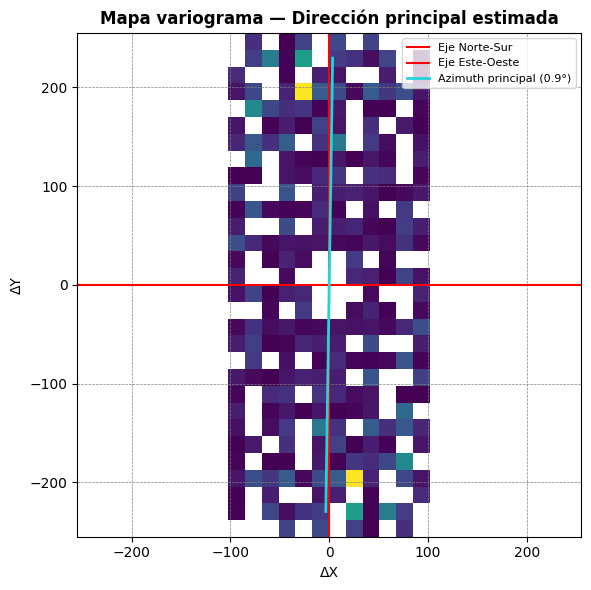

In [ ]:
# --- Plot del mapa con ejes cardinales y la dirección principal estimada ---
plt.figure(figsize=(6,6))
plt.imshow(grid, extent=extent, origin='lower', aspect='equal')

# Ejes cardinales
plt.axvline(0, color="red", label="Eje Norte-Sur")
plt.axhline(0, color="red", label="Eje Este-Oeste")

# Línea de dirección principal (mayor continuidad)
if direction is not None:
    ang = math.radians(direction["Angulo_x_grado"])
    L = 0.9 * max(extent[1] - extent[0], extent[3] - extent[2]) / 2.0
    x0, y0 = 0.0, 0.0
    x1, y1 = x0 + L * math.cos(ang), y0 + L * math.sin(ang)
    x2, y2 = x0 - L * math.cos(ang), y0 - L * math.sin(ang)
    plt.plot([x2, x1], [y2, y1], color="#21D5DB", linewidth=2,
             label=f"Azimuth principal ({direction['Azimuth_norte_grado']:.1f}°)")

plt.title("Mapa variograma — Dirección principal estimada", fontweight='bold', fontsize=12)
plt.xlabel("ΔX"); plt.ylabel("ΔY")
plt.legend(loc="upper right", fontsize=8, frameon=True)
plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('Mapa_variograma_direccion.jpg', dpi=300, format='jpg', bbox_inches='tight')
plt.show()


🧭 1. Qué significa “anisotrópico”

Isotrópico → “igual en todas las direcciones”.
👉 La variabilidad espacial del pH sería la misma si te mueves hacia el norte, sur, este u oeste.
(En el variograma, la nube de puntos formaría un círculo).

Anisotrópico → “distinto según la dirección”.
👉 El pH cambia más rápidamente en una dirección y más lentamente en otra.
(En el variograma, la nube tiene forma ovalada o elíptica).

Cada fila es un intervalo de distancia (lag) con: número de pares N y semivarianza media γ.

Úsalo para ver tendencia: si γ sube con la distancia y luego se estabiliza, hay rango y sill detectables.

In [ ]:
# --- 1. Construcción de pares por índices superiores (más eficiente) ---
coords = gdf_punto[[col_x, col_y]].to_numpy(float)
i, j = np.triu_indices(n, k=1)
h = np.hypot(coords[i,0]-coords[j,0], coords[i,1]-coords[j,1])  # distancia
gamma = 0.5 * (z[i] - z[j])**2

# --- 2. Definir nº de bins (automático según nº de pares) ---
num_bins = 10 if len(h) >= 50 else max(6, int(np.ceil(np.sqrt(len(h)))))
bins = np.linspace(0, h.max(), num_bins + 1)

# --- 3. Construcción de tabla por clases ---
rows = []
for k, (b0, b1) in enumerate(zip(bins[:-1], bins[1:]), start=1):
    # incluir el límite superior en el último bin
    m = (h >= b0) & (h < b1) if k < num_bins else (h >= b0) & (h <= b1)
    rows.append({
        "Clase": k,
        "Rango_h": f"[{b0:.1f}, {b1:.1f}{')' if k < num_bins else ']'}",
        "h_min": float(b0),
        "h_max": float(b1),
        "h_centro": float((b0 + b1) / 2),
        "Num_parejas": int(m.sum()),
        "gamma_media": float(np.nanmean(gamma[m])) if m.any() else float("nan")
    })

tabla = pd.DataFrame(rows).round({"h_min": 4, "h_max": 4, "h_centro": 4, "gamma_media": 4})
tabla


,Clase,Rango_h,h_min,h_max,h_centro,Num_parejas,gamma_media
0,1,"[0.0, 43.4)",0.0000,43.3613,21.6807,18,0.0276
1,2,"[43.4, 86.7)",43.3613,86.7227,65.0420,69,0.0323
2,3,"[86.7, 130.1)",86.7227,130.0840,108.4033,78,0.0426
3,4,"[130.1, 173.4)",130.0840,173.4453,151.7647,58,0.0603
4,5,"[173.4, 216.8)",173.4453,216.8067,195.1260,44,0.0716
5,6,"[216.8, 260.2)",216.8067,260.1680,238.4873,38,0.0802
6,7,"[260.2, 303.5)",260.1680,303.5293,281.8487,31,0.0924
7,8,"[303.5, 346.9)",303.5293,346.8907,325.2100,21,0.0711
8,9,"[346.9, 390.3)",346.8907,390.2520,368.5713,13,0.0648
9,10,"[390.3, 433.6]",390.2520,433.6134,411.9327,8,0.0270



Verifica que cada bin tenga suficientes parejas (N) para que la γ media sea estable (idealmente decenas/centenas).

Bins con muy pocos pares son ruidosos (trata de ajustar num_bins o el rango total).

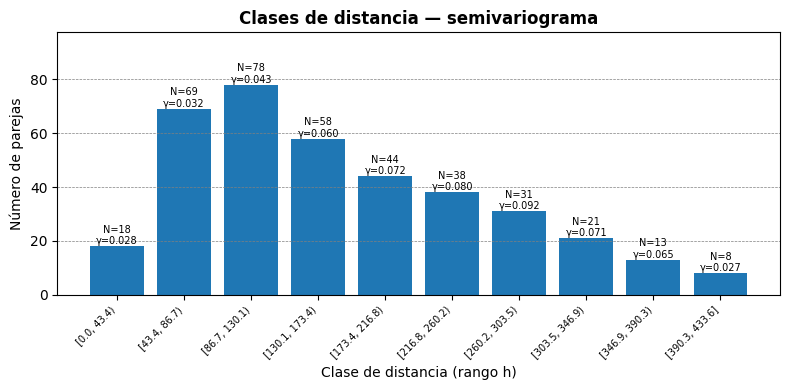

In [ ]:
# Preparar datos para plot
npairs = list(tabla["Num_parejas"])
etiquetas = list(tabla["Rango_h"])
gamma_mean = list(tabla["gamma_media"])

xpos = np.arange(1, len(etiquetas)+1)

plt.figure(figsize=(8,4))
bars = plt.bar(xpos, npairs)
plt.xticks(xpos, etiquetas, rotation=45, ha="right", fontsize=7)
plt.xlabel("Clase de distancia (rango h)", fontsize=10)
plt.ylabel("Número de parejas", fontsize=10)
plt.title("Clases de distancia — semivariograma", fontweight='bold', fontsize=12)

# Etiquetas por barra (N y γ media)
ymax = max(npairs) if npairs else 0
for rect, nbin, g in zip(bars, npairs, gamma_mean):
    height = rect.get_height()
    label = f"N={nbin}"
    if not np.isnan(g):
        label += f"\nγ={g:.3f}"
    plt.text(rect.get_x() + rect.get_width()/2.0, height, label,
             ha='center', va='bottom', fontsize=7)

plt.ylim(0, ymax * 1.25 if ymax>0 else 1)
plt.grid(axis="y", which='both', linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()


Curva típica: γ(h) crece con la distancia y se aplana → sill (varianza espacial total).

El punto de inflexión o donde se aproxima al sill sugiere el rango (más allá, las muestras dejan de “verse”).

Si γ(0) es mayor que 0 (o hay salto inicial), indica nugget (microvariabilidad/ruido de medición).

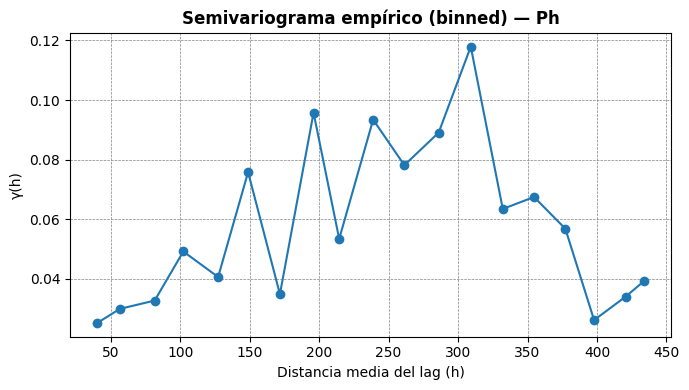

In [ ]:
# Si partimos de gdf_pares (calculado antes):
bins = np.linspace(0, gdf_pares["distancia"].max(), 20)  # nº de intervalos (ajústalo)
gdf_pares["bin"] = np.digitize(gdf_pares["distancia"], bins)

# Promedios por bin (distancia media y γ media)
bin_means = gdf_pares.groupby("bin")[["distancia", "gamma"]].mean()

# --- Plot del semivariograma binned ---
plt.figure(figsize=(7,4))
plt.plot(bin_means["distancia"], bin_means["gamma"], marker='o')
plt.title(f"Semivariograma empírico (binned) — {col_ph}", fontweight='bold', fontsize=12)
plt.xlabel("Distancia media del lag (h)")
plt.ylabel("γ(h)")
plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# RESUMEN GEOESTADÍSTICO + PROMPT
# =========================

import math, json, os, numpy as np, pandas as pd, geopandas as gpd
from itertools import combinations
from shapely.geometry import LineString

# ---------- CONFIG ----------
EXCEL_PATH = "/content/Tabla_suelos.xlsx"   # <-- cambia si es necesario
SHEET_NAME = "Suelo"
COL_X = "X"      # ej. "ESTE"
COL_Y = "Y"      # ej. "NORTE"
COL_VAR = "Ph"   # tu variable (pH)
CRS = "EPSG:32716"  # UTM correcto para tus coordenadas

# Parámetros del variogram map
NBINS = 30
MAX_RANGE_FRAC = 0.6      # porcentaje del tamaño del muestreo
PAIR_CAP = 1_000_000      # tope de pares (usa muestreo si se supera)
RANDOM_STATE = 42

# ---------- UTILIDADES ----------
def build_variogram_map(x, y, z, nbins=80, max_range_frac=0.6, pair_cap=1_000_000, random_state=42):
    x = np.asarray(x, float); y = np.asarray(y, float); z = np.asarray(z, float)
    n = len(z)
    total_pairs = n*(n-1)//2

    if total_pairs > pair_cap:
        rng = np.random.default_rng(random_state)
        K = min(3000, n)
        M = min(50, n-1)
        idx = rng.choice(n, size=K, replace=False)
        pairs = []
        for i in idx:
            others = rng.choice([j for j in range(n) if j != i], size=M, replace=False)
            for j in others:
                a, b = (i, j) if i < j else (j, i)
                pairs.append((a, b))
        pairs = np.unique(np.asarray(pairs, dtype=int), axis=0)
    else:
        pairs = np.array(list(combinations(range(n), 2)), dtype=int)

    dx = x[pairs[:,1]] - x[pairs[:,0]]
    dy = y[pairs[:,1]] - y[pairs[:,0]]
    gamma = 0.5*(z[pairs[:,1]] - z[pairs[:,0]])**2

    width  = x.max() - x.min()
    height = y.max() - y.min()
    Hmax = max_range_frac * max(width, height)

    dist = np.hypot(dx, dy)
    m = dist <= Hmax
    dx = dx[m]; dy = dy[m]; gamma = gamma[m]

    hx_edges = np.linspace(-Hmax, Hmax, nbins+1)
    hy_edges = np.linspace(-Hmax, Hmax, nbins+1)
    hx_centers = 0.5*(hx_edges[:-1] + hx_edges[1:])
    hy_centers = 0.5*(hy_edges[:-1] + hy_edges[1:])

    sums = np.zeros((nbins, nbins), float)
    counts = np.zeros((nbins, nbins), int)

    ix = np.searchsorted(hx_edges, dx, side='right') - 1
    iy = np.searchsorted(hy_edges, dy, side='right') - 1
    valid = (ix >= 0) & (ix < nbins) & (iy >= 0) & (iy < nbins)
    ix = ix[valid]; iy = iy[valid]; g = gamma[valid]

    for cx, cy, val in zip(ix, iy, g):
        sums[cy, cx] += val; counts[cy, cx] += 1
        # simetría (espejo)
        mx = nbins - 1 - cx
        my = nbins - 1 - cy
        sums[my, mx] += val; counts[my, mx] += 1

    with np.errstate(invalid='ignore', divide='ignore'):
        grid = sums / counts
    grid[~np.isfinite(grid)] = np.nan

    extent = (hx_edges[0], hx_edges[-1], hy_edges[0], hy_edges[-1])
    stats = {"n_pairs_used": int(valid.sum())*2, "Hmax": float(Hmax), "nbins": nbins}
    return grid, extent, hx_centers, hy_centers, stats

def estimate_principal_direction(hx_centers, hy_centers, grid):
    HX, HY = np.meshgrid(hx_centers, hy_centers)
    G = np.array(grid, float)
    valid = np.isfinite(G)
    if not np.any(valid):
        return None
    Gmax = np.nanmax(G)
    W = (Gmax - G)
    W[~valid] = 0.0
    W[W < 0] = 0.0

    X = HX.ravel(); Y = HY.ravel(); w = W.ravel()
    wsum = w.sum()
    if wsum == 0:
        return None

    mx = (w*X).sum()/wsum; my = (w*Y).sum()/wsum
    Xc = X - mx; Yc = Y - my
    Sxx = (w*(Xc*Xc)).sum()/wsum
    Syy = (w*(Yc*Yc)).sum()/wsum
    Sxy = (w*(Xc*Yc)).sum()/wsum
    cov = np.array([[Sxx, Sxy],[Sxy, Syy]])
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]; vecs = vecs[:, order]
    v_major = vecs[:,0]

    angle_from_x = (math.degrees(math.atan2(v_major[1], v_major[0])) + 180.0) % 180.0
    az_north = (90.0 - angle_from_x) % 180.0
    ratio = math.sqrt(vals[0]/vals[1]) if vals[1] > 0 else float("inf")
    return {
        "Angulo_x_grado": round(float(angle_from_x), 3),
        "Azimuth_norte_grado": round(float(az_north), 3),
        "Relacion_anisotropia_mayor_menor": round(float(ratio), 3)
    }

def semivariogram_bins(coords, values, n_bins=None):
    n = len(values)
    i, j = np.triu_indices(n, k=1)
    h = np.hypot(coords[i,0]-coords[j,0], coords[i,1]-coords[j,1])
    gamma = 0.5*(values[i] - values[j])**2
    if n_bins is None:
        n_bins = 10 if len(h) >= 50 else max(6, int(np.ceil(np.sqrt(len(h)))))
    bins = np.linspace(0, h.max(), n_bins + 1)

    rows = []
    for k, (b0, b1) in enumerate(zip(bins[:-1], bins[1:]), start=1):
        m = (h >= b0) & (h < b1) if k < n_bins else (h >= b0) & (h <= b1)
        rows.append({
            "Clase": k,
            "h_min": float(b0),
            "h_max": float(b1),
            "h_centro": float((b0 + b1)/2.0),
            "Num_parejas": int(m.sum()),
            "gamma_media": float(np.nanmean(gamma[m])) if m.any() else float("nan")
        })
    tabla = pd.DataFrame(rows)
    return tabla, h, gamma

# ---------- 1) CARGA Y GDF ----------
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
for c in [COL_X, COL_Y, COL_VAR]:
    assert c in df.columns, f"Falta la columna requerida: {c}"
df[COL_VAR] = pd.to_numeric(df[COL_VAR], errors="coerce")

gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[COL_X], df[COL_Y]),
    crs=CRS
)

x = gdf[COL_X].to_numpy(float)
y = gdf[COL_Y].to_numpy(float)
z = gdf[COL_VAR].to_numpy(float)
coords = gdf[[COL_X, COL_Y]].to_numpy(float)
n = len(z)

# ---------- 2) NUBE DE PARES (para referencia) ----------
pares = []
for (i1, p1), (i2, p2) in combinations(gdf.iterrows(), 2):
    x1, y1, v1 = p1[COL_X], p1[COL_Y], p1[COL_VAR]
    x2, y2, v2 = p2[COL_X], p2[COL_Y], p2[COL_VAR]
    dist = np.hypot(x2 - x1, y2 - y1)
    gamma = 0.5*(v2 - v1)**2
    pares.append({"distancia": dist, "gamma": gamma, "geometry": LineString([(x1, y1), (x2, y2)])})
gdf_pares = gpd.GeoDataFrame(pares, crs=gdf.crs)

# ---------- 3) MAPA DE VARIOGRAMA + DIRECCIÓN ----------
grid, extent, hx_c, hy_c, stats = build_variogram_map(
    x, y, z, nbins=NBINS, max_range_frac=MAX_RANGE_FRAC, pair_cap=PAIR_CAP, random_state=RANDOM_STATE
)
direction = estimate_principal_direction(hx_c, hy_c, grid)

# ---------- 4) SEMIVARIOGRAMA BINNED ----------
tabla_bins, h_all, gamma_all = semivariogram_bins(coords, z, n_bins=None)

# ---------- 5) RESUMEN COMPACTO ----------
def resumen_texto(df, gdf, gdf_pares, stats, direction, tabla_bins, col_var):
    lines = []
    lines.append("=== RESUMEN GEOESTADÍSTICO ===")
    lines.append(f"Variable: {col_var}")
    lines.append(f"N puntos: {len(df)}")
    lines.append(f"CRS: {getattr(gdf, 'crs', None)}")
    lines.append("")
    lines.append("--- Variogram Map (parámetros) ---")
    for k,v in stats.items():
        if isinstance(v, float):
            lines.append(f"{k}: {v:.3f}")
        else:
            lines.append(f"{k}: {v}")
    lines.append("")
    if direction is not None:
        lines.append("--- Anisotropía estimada ---")
        lines.append(f"Ángulo desde +X (°): {direction['Angulo_x_grado']}")
        lines.append(f"Azimut desde Norte (°): {direction['Azimuth_norte_grado']}")
        lines.append(f"Relación mayor/menor: {direction['Relacion_anisotropia_mayor_menor']}")
    else:
        lines.append("No se pudo estimar dirección principal (grid vacío).")
    lines.append("")
    lines.append("--- Semivariograma binned (primeras filas) ---")
    head = tabla_bins.head(8).copy()
    lines.append(head.to_string(index=False, justify='center'))
    lines.append("")
    lines.append("Notas rápidas de lectura:")
    lines.append("* γ(h) baja en distancias cortas y aumento hacia un sill sugiere autocorrelación.")
    lines.append("* Azimut ≈ dirección de mayor continuidad; relación >1 confirma anisotropía geométrica.")
    return "\n".join(lines)

resumen = resumen_texto(df, gdf, gdf_pares, stats, direction, tabla_bins, COL_VAR)

# ---------- 6) GUARDAR A DISCO ----------
os.makedirs("./salidas_geo", exist_ok=True)
TXT_PATH = "./salidas_geo/resumen_variograma.txt"
JSON_PATH = "./salidas_geo/resumen_variograma.json"
EXCEL_BINS = "./salidas_geo/semivariograma_binned.xlsx"

with open(TXT_PATH, "w", encoding="utf-8") as f:
    f.write(resumen)

payload = {
    "variable": COL_VAR,
    "n_puntos": int(len(df)),
    "crs": str(getattr(gdf, "crs", None)),
    "variogram_map_params": stats,
    "anisotropia": direction,
    "semivariograma_binned_head": tabla_bins.head(20).to_dict(orient="records")
}
with open(JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

tabla_bins.to_excel(EXCEL_BINS, index=False)

# ---------- 7) PROMPT PARA CHATGPT ----------
PROMPT_PARA_CHATGPT = f"""
Quiero una interpretación completa y accionable de un análisis geoestadístico de suelos (variable: {COL_VAR}).
Te paso un RESUMEN estructurado (entre <<< >>>). Por favor:
1) Explica si hay isotropía/anisotropía, con la dirección y su significado práctico.
2) Interpreta γ(h): nugget, tendencia hacia el sill y rango aproximado.
3) Da recomendaciones para modelado del variograma (esférico/exp/gauss), y cómo setear anisotropía geométrica (azimut y razón).
4) Propón validaciones (variogramas direccionales, CV del kriging) y qué métricas mirar.
5) Sugiere decisiones de muestreo o manejo del suelo basadas en el patrón observado.

<<<
{resumen}
>>>

Además, usa el JSON si lo necesitas (estructura lista para parsear):
{json.dumps(payload, ensure_ascii=False, indent=2)}
"""

with open("./salidas_geo/PROMPT_CHATGPT.txt", "w", encoding="utf-8") as f:
    f.write(PROMPT_PARA_CHATGPT)

print("Listo ✅")
print(f"- Resumen TXT: {TXT_PATH}")
print(f"- Resumen JSON: {JSON_PATH}")
print(f"- Semivariograma (bins) XLSX: {EXCEL_BINS}")
print(f"- PROMPT para ChatGPT: ./salidas_geo/PROMPT_CHATGPT.txt")


Listo ✅
- Resumen TXT: ./salidas_geo/resumen_variograma.txt
- Resumen JSON: ./salidas_geo/resumen_variograma.json
- Semivariograma (bins) XLSX: ./salidas_geo/semivariograma_binned.xlsx
- PROMPT para ChatGPT: ./salidas_geo/PROMPT_CHATGPT.txt
